In [ ]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import numpy as np 
import pandas as pd
import datetime
import xarray as xr 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import calendar
from zhiyi.analysis.SE_analysis import get_site_index 
from matplotlib.lines import Line2D
from scipy.spatial import cKDTree
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
print("done")


done


In [ ]:
SCRIP_file = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"
SCRIP_file_ne60 ="/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"

filebase_ne30 = ('/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/'
                 'MUSICA_production3.0.cam.h2.YYYY-MM-DD-03600.nc')
filebase_ne60 = ('/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/'
                 'MUSICA_production3.0_NOBB.cam.h2.YYYY-MM-DD-03600.nc')

city_lonlat = {
    'London':     [360 - 0.213492,  51.521050],
    'Manchester': [360 - 2.237881,  53.481520],
    'Glasgow':    [360 - 4.259122,  55.858940],
    'Birmingham': [360 - 1.874978,  52.476145],
}
obs_files = {
    'London':     '/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/P1_o3/london_o3.csv',
    'Manchester': '/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/P1_o3/manchester_o3.csv',
    'Glasgow':    '/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/P1_o3/glasgow_o3.csv',
    'Birmingham': '/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/P1_o3/birmingham_o3.csv'}
obs_factors = {'London':0.5033, 'Manchester':0.5007, 'Glasgow':0.5, 'Birmingham':0.5005} #ug/m3 to ppbv
K_NE30 = 36
K_NE60 = 36



In [ ]:

def collect_files(template, start, end):
    files = []
    by_day = ("DD" in template)

    cur = start
    while cur <= end:
        YYYY = cur.strftime("%Y")
        MM   = cur.strftime("%m")
        DD   = cur.strftime("%d")

        f = (template
             .replace("YYYY", YYYY)
             .replace("MM", MM)
             .replace("DD", DD))

        if os.path.exists(f):
            files.append(f)
        else:
            print(f"Warning: File not found - {f}, skipping.")
        if by_day:
            cur += datetime.timedelta(days=1)
        else:
            if cur.month == 12:
                cur = datetime.date(cur.year + 1, 1, 1)
            else:
                cur = datetime.date(cur.year, cur.month + 1, 1)
    if not files:
        raise FileNotFoundError(
            f"No files found for template '{template}' between {start} and {end}."
        )
    return files

def lonlat_to_deg(lon, lat):
    if np.nanmax(np.abs(lat)) <= 3.2 and np.nanmax(np.abs(lon)) <= 3.2:
        lon = np.rad2deg(lon)
        lat = np.rad2deg(lat)
    return lon, lat

def get_site_indices(lon360_c, lat_c, scrip_file, k=1):
    ds = xr.open_dataset(scrip_file)
    glon = ds['grid_center_lon'].values
    glat = ds['grid_center_lat'].values
    glon, glat = lonlat_to_deg(glon, glat)
    glon180 = (glon + 180) % 360 - 180
    lon180_c = (lon360_c + 180) % 360 - 180
    tree = cKDTree(np.vstack([glat, glon180]).T)
    _, idx = tree.query([lat_c, lon180_c], k=k)
    ds.close()
    idx = np.atleast_1d(idx).astype(int)
    return idx

def mda8_from_hourly_matrix(values_mat, times, min_hours=6):
    k = values_mat.shape[1]
    mda8_list = []
    for j in range(k):
        s = pd.Series(np.asarray(values_mat[:, j], float),
                      index=pd.to_datetime(times)).sort_index()
        roll8 = s.rolling(window=8, min_periods=min_hours).mean()
        mda8 = roll8.resample('D').max()
        mda8_list.append(mda8)
    mda8_df = pd.concat(mda8_list, axis=1) 
    out = {
        'mean': mda8_df.mean(axis=1),
        'min':  mda8_df.min(axis=1),
        'max':  mda8_df.max(axis=1),
    }
    return out

def load_obs_hourly(path, start_ts, end_ts, ycol='average'):
    df = pd.read_csv(path)
    df['Date'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str), errors='coerce')
    end_excl = pd.to_datetime(end_ts) + pd.Timedelta(days=1)
    df = df[(df['Date'] >= pd.to_datetime(start_ts)) & (df['Date'] < end_excl)].sort_values('Date').copy()
    return df

def mda8_from_hourly(values, times, min_hours=6):
    s = pd.Series(np.asarray(values, float), index=pd.to_datetime(times)).sort_index()
    roll8 = s.rolling(window=8, min_periods=min_hours).mean()
    mda8 = roll8.resample('D').max()
    return mda8

def mda8_obs_from_df(obs_df, ycol='average', factor=1.0, min_hours=6):
    s = pd.Series(obs_df[ycol].values * factor, index=obs_df['Date']).sort_index()
    roll8 = s.rolling(window=8, min_periods=min_hours).mean()
    return roll8.resample('D').max()


In [ ]:

se_files_30 = collect_files(filebase_ne30, start_date, end_date)
se_files_60 = collect_files(filebase_ne60, start_date, end_date)

ds_ne30 = xr.open_mfdataset(se_files_30, combine="by_coords")
ds_ne60 = xr.open_mfdataset(se_files_60, combine="by_coords")
print("Datasets loaded!")

time_values_local = (
    pd.to_datetime(ds_ne30.time.values)
      .tz_localize('UTC')
      .tz_convert('Europe/London')
      .tz_localize(None)
)
time_values_nobb_local = (
    pd.to_datetime(ds_ne60.time.values)
      .tz_localize('UTC')
      .tz_convert('Europe/London')
      .tz_localize(None)
)

Index_lonlat_30 = {c: get_site_indices(lon, lat, SCRIP_file, k=K_NE30)       for c,(lon,lat) in city_lonlat.items()}
Index_lonlat_60 = {c: get_site_indices(lon, lat, SCRIP_file_ne60, k=K_NE60)  for c,(lon,lat) in city_lonlat.items()}

TS_mat     = {}
TS_mat_f09 = {}
for c in city_lonlat:
    idxs30 = Index_lonlat_30[c]
    idxs60 = Index_lonlat_60[c]
    TS_mat[c]     = ds_ne30['O3'].values[:, -1, idxs30] * 1e9
    TS_mat_f09[c] = ds_ne60['O3'].values[:, -1, idxs60] * 1e9



Datasets loaded!


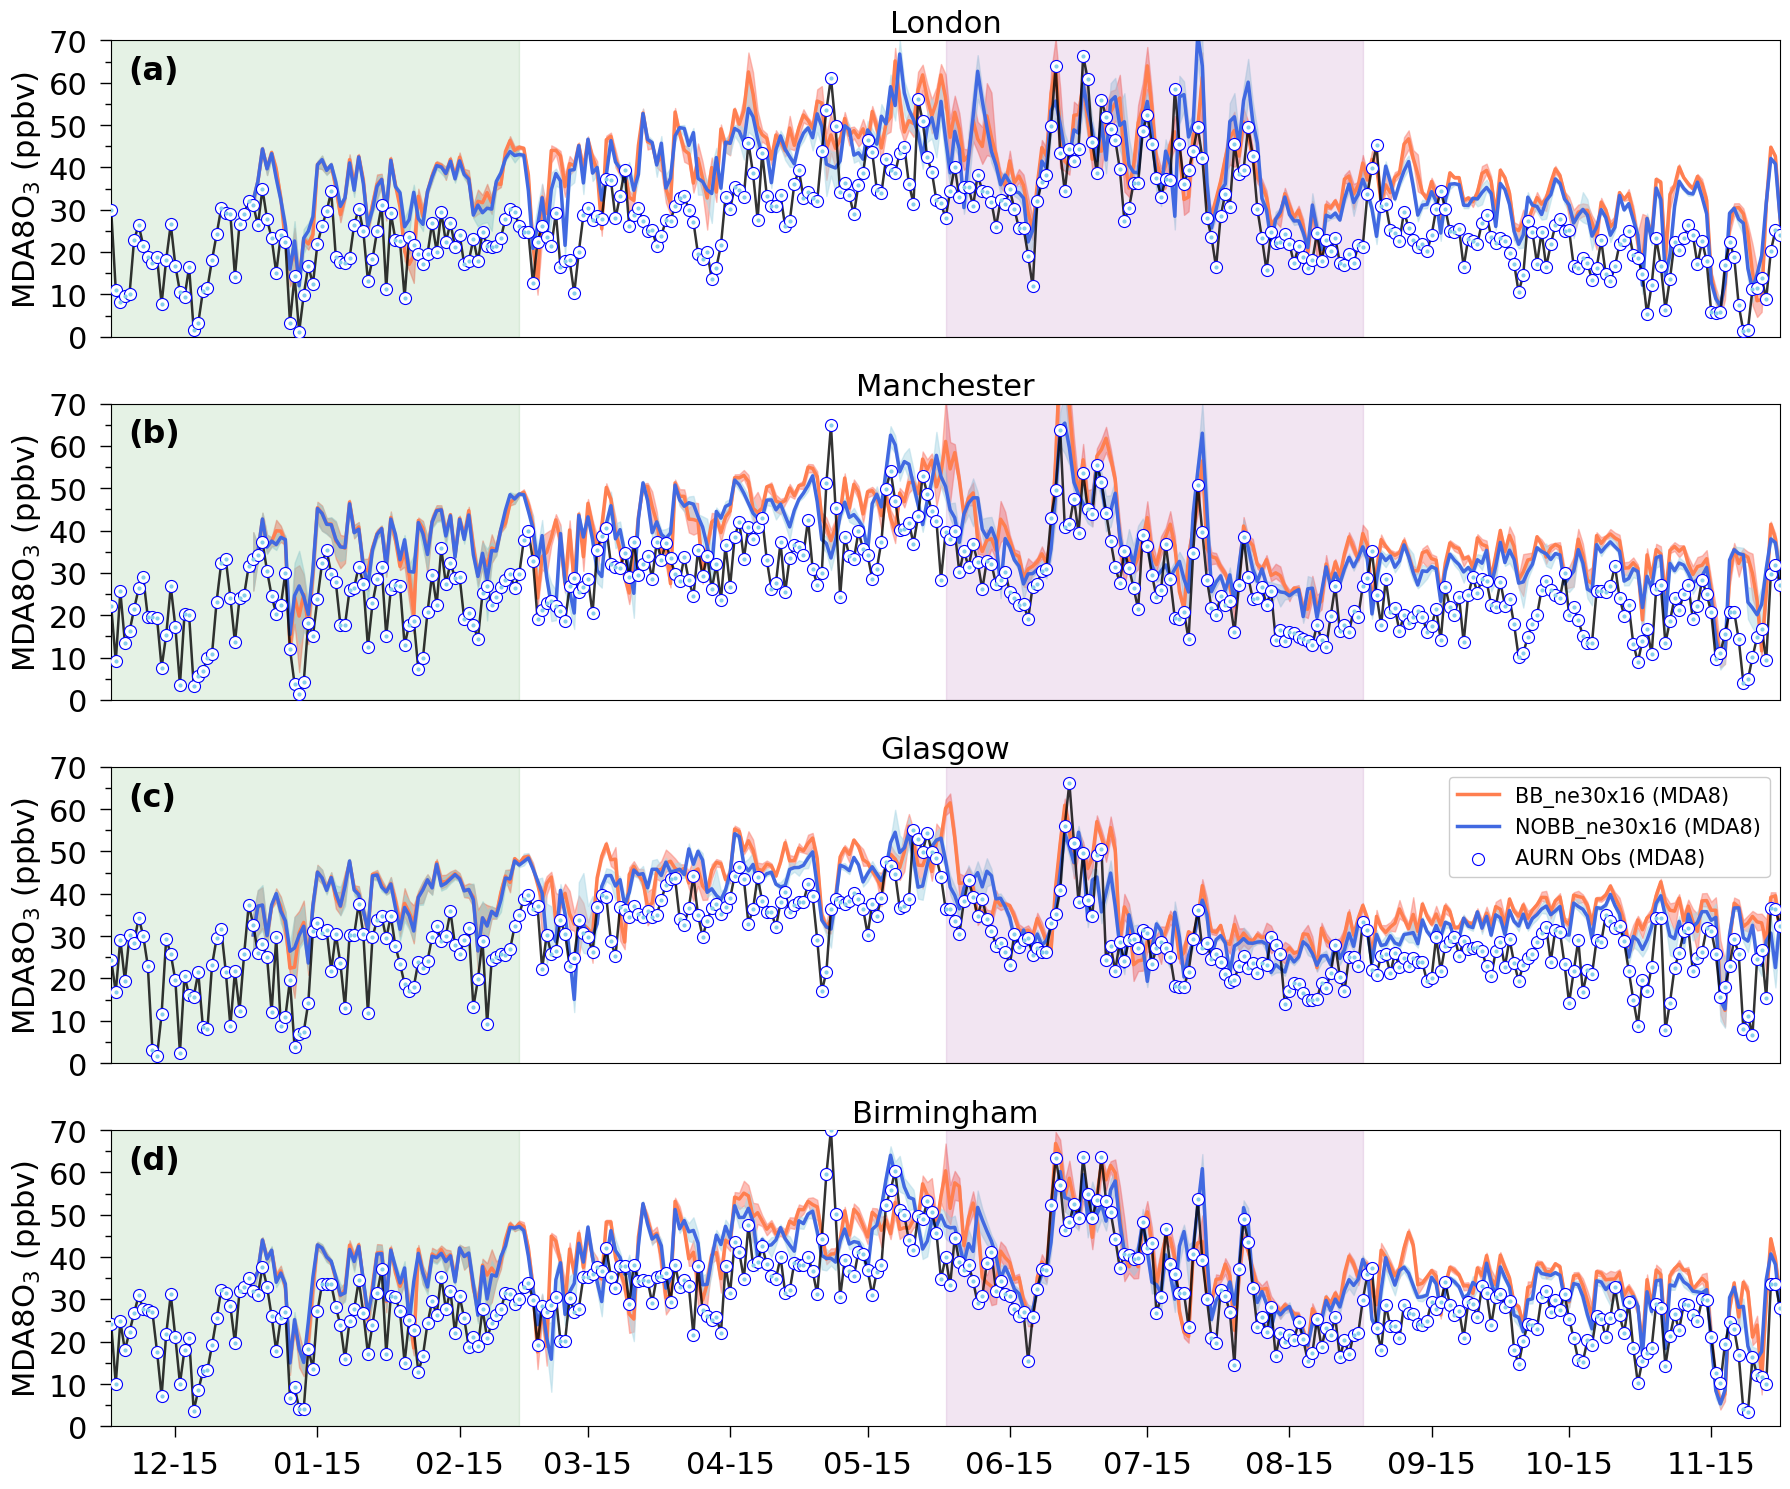

In [ ]:

cities = list(city_lonlat.keys())
fig, axes = plt.subplots(4, 1, figsize=(18, 15))

month_locator   = mdates.MonthLocator(bymonthday=15, interval=1)
month_formatter = mdates.DateFormatter('%m-%d')
plot_start_obs = pd.to_datetime('2017-12-01')
plot_end_obs   = pd.to_datetime('2018-11-30')

obs_hourly = {city: load_obs_hourly(obs_files[city], plot_start_obs, plot_end_obs, ycol='average')
              for city in city_lonlat}
MDA8_OBS = {city: mda8_obs_from_df(obs_hourly[city], ycol='average', factor=obs_factors[city])
            for city in city_lonlat}

MDA8_30 = {}
MDA8_60 = {}
for city in city_lonlat:
    MDA8_30[city] = mda8_from_hourly_matrix(TS_mat[city],     time_values_local)
    MDA8_60[city] = mda8_from_hourly_matrix(TS_mat_f09[city], time_values_nobb_local)

for i, city in enumerate(cities):
    ax = axes[i]
    ax.fill_between(MDA8_30[city]['mean'].index,
                    MDA8_30[city]['min'].values,
                    MDA8_30[city]['max'].values,
                    alpha=0.50, zorder=0, color='salmon')
    ax.plot(MDA8_30[city]['mean'].index,
            MDA8_30[city]['mean'].values,
            color='coral', linewidth=2.5, label='BB_ne30x16 (MDA8)')
    ax.fill_between(MDA8_60[city]['mean'].index,
                    MDA8_60[city]['min'].values,
                    MDA8_60[city]['max'].values,
                    alpha=0.5, zorder=0, color='lightblue')
    ax.plot(MDA8_60[city]['mean'].index,
            MDA8_60[city]['mean'].values,
            color='royalblue', linewidth=2.5, label='NOBB_ne30x16 (MDA8)')
    ax.plot(
        MDA8_OBS[city].index,
        MDA8_OBS[city].values,
        color='black',
        linewidth=1.8,
        alpha=0.8,
        zorder=9,
        label=None
    )
    ax.scatter(
        MDA8_OBS[city].index, MDA8_OBS[city].values,
        s=75,
        c='white',
        edgecolors='blue',
        linewidths=0.8,
        alpha=1,
        label='AURN Obs (MDA8)',
        zorder=10
    )
    ax.scatter(
        MDA8_OBS[city].index, MDA8_OBS[city].values,
        s=4,
        c='skyblue',
        zorder=10             
    )
    ax.axvspan(pd.to_datetime('2017-12-01'), pd.to_datetime('2018-02-28'), color='green', alpha=0.1, zorder=0)
    ax.axvspan(pd.to_datetime('2018-06-01'), pd.to_datetime('2018-08-31'), color='purple', alpha=0.1, zorder=0)
    ax.set_title(city, fontsize=22)
    ax.set_ylabel('MDA8O$_{3}$ (ppbv)', fontsize=22)
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.set_ylim(0, 70)
    ax.tick_params(axis='y', which='major', labelsize=22, pad=9, length=8, width=1)
    ax.tick_params(axis='y', which='minor', labelsize=18*0.8, length=4, width=1)
    
    plot_start = pd.to_datetime('2017-12-01')
    plot_end   = pd.to_datetime('2018-11-30')
    ax.set_xlim(plot_start_obs, plot_end_obs)
    ax.xaxis.set_major_locator(month_locator)
    ax.xaxis.set_major_formatter(month_formatter)
    
    if i == 2:
        ax.legend(fontsize=15, loc='upper right',framealpha=1.0)
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    elif i < len(cities) - 1:
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    else:
        ax.tick_params(axis='x', which='major', labelsize=22, pad=9, length=8, width=1)
        ax.tick_params(axis='x', which='minor', labelsize=18*0.8, length=4, width=1)

labels = ['(a)', '(b)', '(c)', '(d)']
for i, city in enumerate(cities):
    ax = axes[i]
    ax.text(
        0.01, 0.95, labels[i],
        transform=ax.transAxes, 
        fontsize=23, 
        fontweight='bold', 
        va='top', ha='left'
    )
    
plt.tight_layout(h_pad=1.3)
